### Фокин Никита 5130901/30201

## Упражнения к главе 11

### Упражнение 11.3

Загрузим аудиозапись барабана:

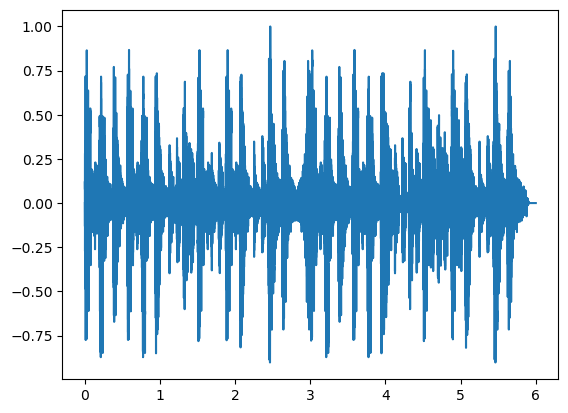

In [53]:
from thinkdsp import read_wave

wave = read_wave('263868__kevcio__amen-break-a-160-bpm.wav')
wave.normalize()
wave.plot()

Спектр аудиозаписи:

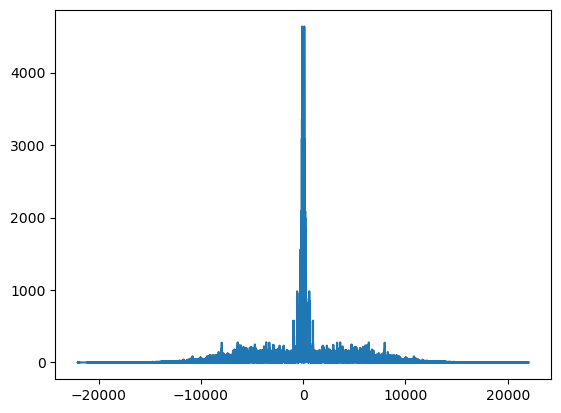

In [54]:
spectrum = wave.make_spectrum(full=True)
spectrum.plot()

Теперь уменьшим частоту дискретизации в 5 раз:

In [55]:
factor = 5
framerate = wave.framerate / factor

Обрежем частоты выше framerate/2

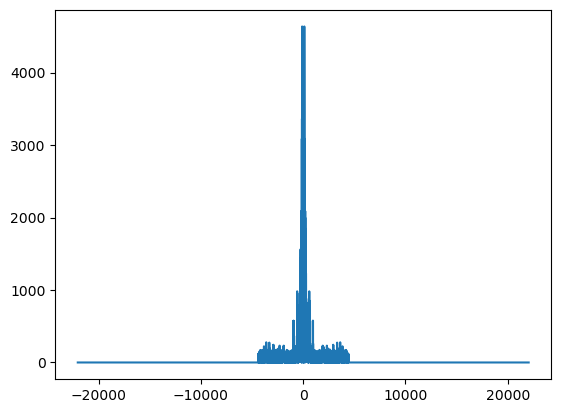

In [56]:
spectrum.low_pass(framerate / 2 - 1)
spectrum.plot()

In [57]:
filtered = spectrum.make_wave()
filtered.make_audio()

Функция вызятия выборок:

In [58]:
from thinkdsp import Wave
import numpy as np

def sample(wave, factor):
    ys = np.zeros(len(wave))
    ys[::factor] = np.real(wave.ys[::factor])
    return Wave(ys, framerate=wave.framerate) 

In [59]:
sampled = sample(filtered, factor)
sampled.make_audio()

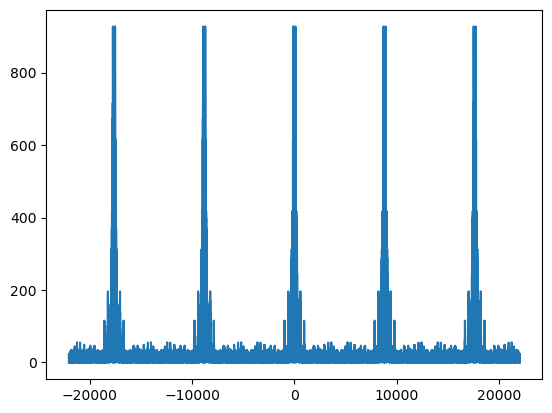

In [60]:
sampledSpec = sampled.make_spectrum(full=True)
sampledSpec.plot()

Применим фильтр сглаживания, чтобы избавиться от спектральных копий:

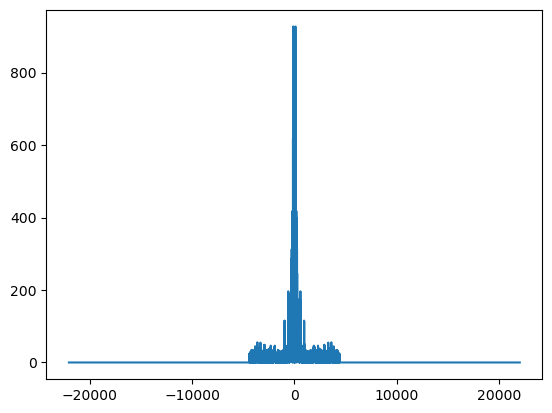

In [61]:
sampledSpec.low_pass(cutoff)
sampledSpec.plot()

Масштабируем спектр:

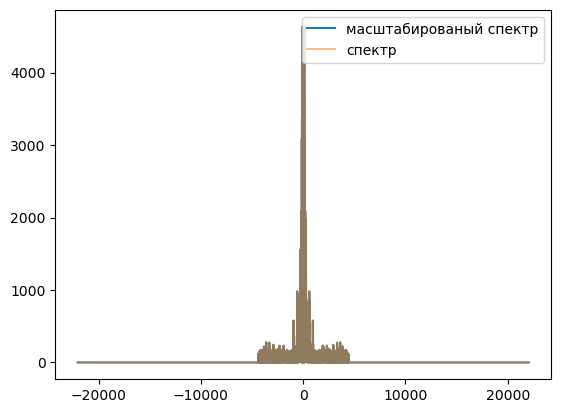

In [62]:
import matplotlib.pyplot as plt

sampledSpec.scale(factor)
sampledSpec.plot(label='масштабированый спектр')
spectrum.plot(label='спектр', alpha=0.5)
plt.legend()

In [63]:
spectrum.max_diff(sampledSpec)

np.float64(1.3689708087886509e-12)

Преобразуем полученный спектр обратно в волну:

In [64]:
wave = sampledSpec.make_wave()
wave.make_audio()

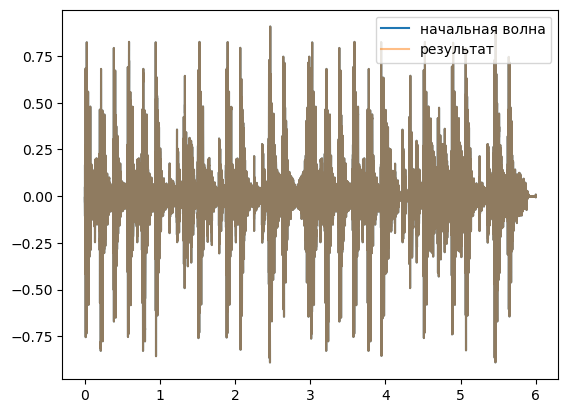

In [65]:
filtered.plot(label='начальная волна')
wave.plot(label='результат', alpha=0.5)
plt.legend()

In [66]:
filtered.max_diff(wave)

np.float64(5.585159539892284e-16)

Таким образом, получаем результат, идентичный отфильтрованному